In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
file_path = '../data/'
co2_emissions = pd.read_csv(file_path + 'annual-co2-emissions-per-country/annual-co2-emissions-per-country.csv')
#df_production = pd.read_csv(file_path + 'nuclear-renewables-and-other-production-qbtu.csv')
#countries = np.array(df_consumption['Country'])
#years = np.array([int(i) for i in df_consumption.keys()[2:]])
#np.where(countries='')
temperature_anomaly = pd.read_csv(file_path + 'temperature-anomaly/temperature-anomaly.csv')

co2_emission_index = np.where(np.array((co2_emissions['Entity'])=='World'))
temperature_anomaly_index = np.where(np.array((temperature_anomaly['Entity'])=='World'))

world_T_anom = temperature_anomaly.iloc[int(min(temperature_anomaly_index[0])):int(max(temperature_anomaly_index[0]))+1]
world_co2_emission = co2_emissions.iloc[int(min(co2_emission_index[0])):int(max(co2_emission_index[0]))+1]
world_co2_emission_years = np.array(world_co2_emission['Year'])
world_T_anom_years = np.array(world_T_anom['Year'])


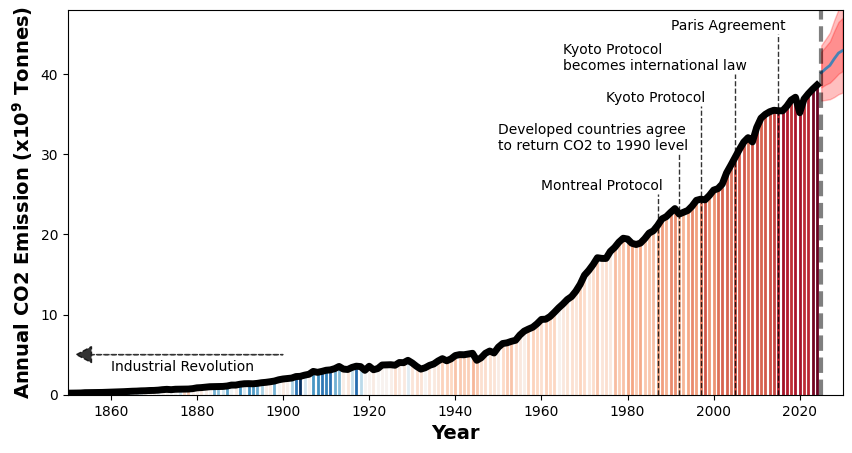

In [107]:
forecast = True
data_emission_np = np.array(world_co2_emission['Annual CO₂ emissions'])
data_temperature_np = np.array(world_T_anom['Average'])
fig = plt.figure(figsize=(10, 5))

sorted_temperature, sorted_years = zip(*sorted(zip(data_temperature_np, world_T_anom_years)))

# Create normalization centered at 0
norm = TwoSlopeNorm(vmin=min(sorted_temperature), vcenter=0, vmax=max(sorted_temperature))

# Generate colors using normalized values
colors = cm.RdBu_r(norm(sorted_temperature))

# Plot
for x, y, c in zip(sorted_years, sorted_temperature, colors):
    #plt.scatter(x, y, color=c)
    if x in world_co2_emission_years:
        index_of_year = np.where(world_co2_emission_years==x)

        plt.vlines(x=x, ymin=0, ymax=data_emission_np[index_of_year]/(1*10**9), linewidth=2, color=c)


#plt.show()
plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black')

plt.ylabel(r'Annual CO2 Emission (x$\mathbf{10^9}$ Tonnes)', weight='bold',fontsize=14)
plt.xlabel('Year', weight='bold',fontsize=14)

plt.ylim(0,48)

#Montreal Protocol
plt.vlines(x=1987,ymin=0,ymax=25,linewidth=1,color='black', linestyles='--',alpha=0.8)
plt.text(1960, 25.5, 'Montreal Protocol')

#Arrow for industrial revolution
plt.arrow(x=1900, y=5, dx=-48, dy=0,  # x=1900, dx=-(xmax-xmin)
          head_width=2, head_length=3.5,
          fc='black', ec='black', 
          ls='--', linewidth=1, alpha=0.8,
          length_includes_head=True)
plt.text(1860, 3, 'Industrial Revolution')

#
plt.vlines(x=1992,ymin=0,ymax=30,linewidth=1,color='black', linestyles='--',alpha=0.8)
plt.text(1950, 30.5, 'Developed countries agree \nto return CO2 to 1990 level')


plt.vlines(x=1997,ymin=0,ymax=36,linewidth=1,color='black', linestyles='--',alpha=0.8)
plt.text(1975, 36.5, 'Kyoto Protocol')#\nDeveloped countries pledge \nto reduce emissions by 5%')


plt.vlines(x=2005,ymin=0,ymax=40,linewidth=1,color='black', linestyles='--',alpha=0.8)
plt.text(1965, 40.5, 'Kyoto Protocol \nbecomes international law')#\nDeveloped countries pledge \nto reduce emissions by 5%')

plt.vlines(x=2015,ymin=0,ymax=45,linewidth=1,color='black', linestyles='--',alpha=0.8)
plt.text(1990, 45.5, 'Paris Agreement')#\nDeveloped countries pledge \nto reduce emissions by 5%')
if forecast:
    plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black',linewidth=5)

    carbon_prediction = np.load('processed_data/Carbon_data_prediction_6_yrs.npy')/(1*10**9)
    plt.fill_between(
        list(range(2025,2031)), carbon_prediction[0][:,0], carbon_prediction[0][:,-1], where=(carbon_prediction[0][:,-1]> carbon_prediction[0][:,0]), 
        interpolate=True, color="red", alpha=0.25, 
        label="Positive"
    )
    plt.fill_between(
        list(range(2025,2031)), carbon_prediction[0][:,1], carbon_prediction[0][:,-2], where=(carbon_prediction[0][:,1]> carbon_prediction[0][:,0]), 
        interpolate=True, color="red", alpha=0.25, 
        label="Positive"
    )
    plt.fill_between(
        list(range(2025,2031)), carbon_prediction[0][:,2], carbon_prediction[0][:,-3], where=(carbon_prediction[0][:,2]> carbon_prediction[0][:,-3]), 
        interpolate=True, color="red", alpha=0.25, 
        label="Positive"
    )
    plt.plot(list(range(2025,2031)),carbon_prediction[0][:,3],color='steelblue',linewidth=2)
    plt.vlines(x=2025,ymin=0,ymax=50,linewidth=3,color='black', linestyles='--',alpha=0.5)
   # plt.text(2020, 40, 'Today', fontsize=15)#\nDeveloped countries pledge \nto reduce emissions by 5%')
    plt.xlim(1850,2030)
else:
    plt.xlim(1850,2023)
plt.savefig('CO2_and_T_anom.png', dpi=300)


1987
1992
1997
2005
2015


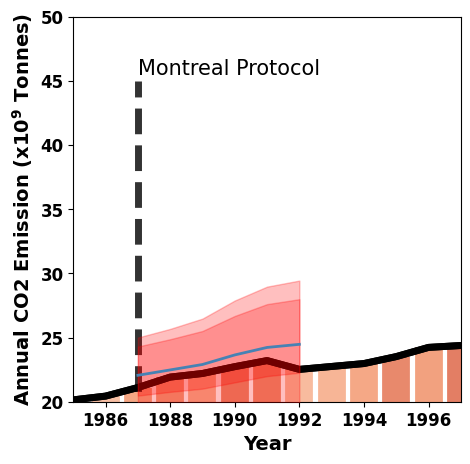

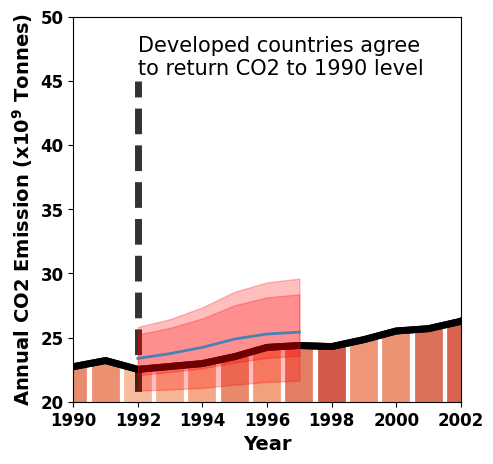

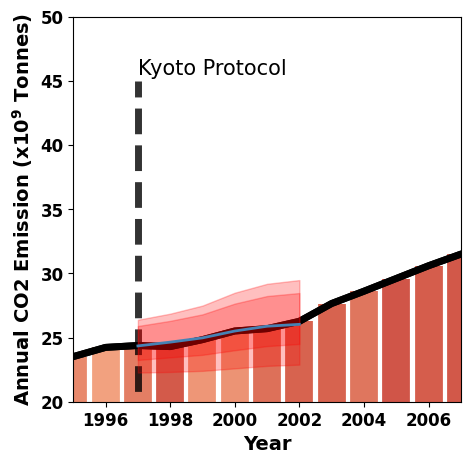

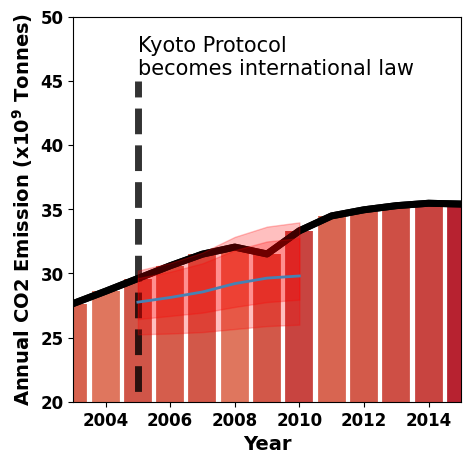

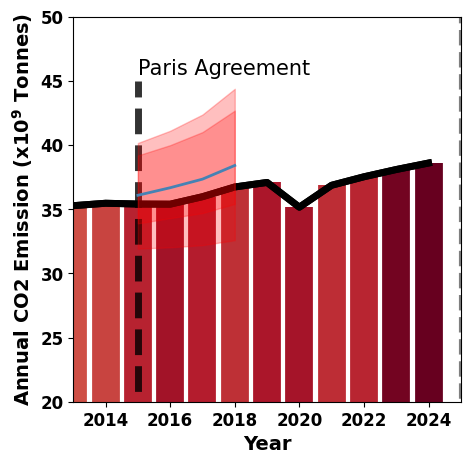

In [124]:
"""
Different parts zoomed in
"""
year_under_consideration_ = [1987,1992,1997,2005,2015]

str_variables_ = ['Montreal Protocol','Developed countries agree \nto return CO2 to 1990 level','Kyoto Protocol','Kyoto Protocol \nbecomes international law','Paris Agreement']
for year_under_consideration,str_variables in zip(year_under_consideration_,str_variables_):
    data_emission_np = np.array(world_co2_emission['Annual CO₂ emissions'])
    data_temperature_np = np.array(world_T_anom['Average'])
    fig = plt.figure(figsize=(5, 5))

    sorted_temperature, sorted_years = zip(*sorted(zip(data_temperature_np, world_T_anom_years)))

    # Create normalization centered at 0
    norm = TwoSlopeNorm(vmin=min(sorted_temperature), vcenter=0, vmax=max(sorted_temperature))

    # Generate colors using normalized values
    colors = cm.RdBu_r(norm(sorted_temperature))

    # Plot
    for x, y, c in zip(sorted_years, sorted_temperature, colors):
        #plt.scatter(x, y, color=c)
        if x in world_co2_emission_years:
            index_of_year = np.where(world_co2_emission_years==x)

            plt.vlines(x=x, ymin=0, ymax=data_emission_np[index_of_year]/(1*10**9), linewidth=20, color=c)


    #plt.show()
    plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black',linewidth=5)

    #plt.ylabel(r'Annual CO2 Emission (x$\mathbf{10^9}$ Tonnes)', weight='bold',fontsize=14)
    #plt.xlabel('Year', weight='bold',fontsize=14)
    plt.vlines(x=year_under_consideration,ymin=0,ymax=45,linewidth=5,color='black', linestyles='--',alpha=0.8)
    plt.text(year_under_consideration, 45.5, str_variables,fontsize=15)
    plt.xticks(fontweight = 'bold',fontsize=12)

    plt.yticks(fontweight = 'bold',fontsize=12)

    plt.xlim(year_under_consideration-2,year_under_consideration+10)
    plt.ylim(20,50)
    if forecast:
        plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black',linewidth=5)
        print(year_under_consideration)
        carbon_prediction = np.load('processed_data/Carbon_data_prediction_6_yrs_backwards_'+str(year_under_consideration)+'.npy')/(1*10**9)
        if year_under_consideration == 2015:
            x = list(range(year_under_consideration,year_under_consideration+4))
        else:
            x = list(range(year_under_consideration,year_under_consideration+6))
        plt.fill_between(x, carbon_prediction[0][:,0], carbon_prediction[0][:,-1], where=(carbon_prediction[0][:,-1]> carbon_prediction[0][:,0]), 
            interpolate=True, color="red", alpha=0.25, 
            label="Positive",zorder=100
        )
        plt.fill_between(x, carbon_prediction[0][:,1], carbon_prediction[0][:,-2], where=(carbon_prediction[0][:,1]> carbon_prediction[0][:,0]), 
            interpolate=True, color="red", alpha=0.25, 
            label="Positive",zorder=100
        )
        plt.fill_between(x, carbon_prediction[0][:,2], carbon_prediction[0][:,-3], where=(carbon_prediction[0][:,2]> carbon_prediction[0][:,-3]), 
            interpolate=True, color="red", alpha=0.25, 
            label="Positive",zorder=100
        )
        plt.plot(x,carbon_prediction[0][:,3],color='steelblue',linewidth=2,zorder=100)
        plt.vlines(x=2025,ymin=0,ymax=50,linewidth=3,color='black', linestyles='--',alpha=0.5)
    # plt.text(2020, 40, 'Today', fontsize=15)#\nDeveloped countries pledge \nto reduce emissions by 5%')
    #plt.axis('off')  # Hide both axes
    plt.ylabel(r'Annual CO2 Emission (x$\mathbf{10^9}$ Tonnes)', weight='bold',fontsize=14)
    plt.xlabel('Year', weight='bold',fontsize=14)
    plt.savefig('CO2_and_T_anom_subset_'+str(year_under_consideration_)+'.png', dpi=300)

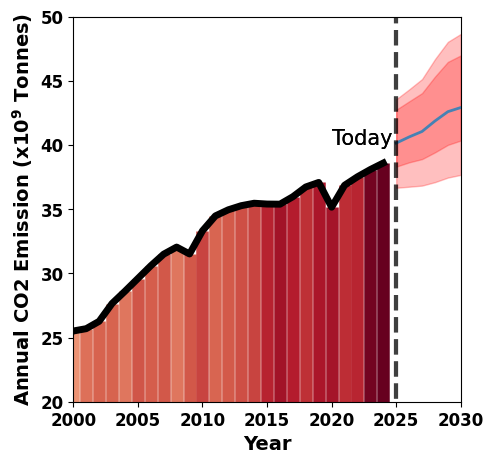

In [125]:
"""
With future predictions
"""

data_emission_np = np.array(world_co2_emission['Annual CO₂ emissions'])
data_temperature_np = np.array(world_T_anom['Average'])
fig = plt.figure(figsize=(5, 5))

sorted_temperature, sorted_years = zip(*sorted(zip(data_temperature_np, world_T_anom_years)))

# Create normalization centered at 0
norm = TwoSlopeNorm(vmin=min(sorted_temperature), vcenter=0, vmax=max(sorted_temperature))

# Generate colors using normalized values
colors = cm.RdBu_r(norm(sorted_temperature))

# Plot
for x, y, c in zip(sorted_years, sorted_temperature, colors):
    #plt.scatter(x, y, color=c)
    if x in world_co2_emission_years:
        index_of_year = np.where(world_co2_emission_years==x)

        plt.vlines(x=x, ymin=0, ymax=data_emission_np[index_of_year]/(1*10**9), linewidth=9, color=c)


#plt.show()
plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black',linewidth=5)

carbon_prediction = np.load('processed_data/Carbon_data_prediction_6_yrs.npy')/(1*10**9)
plt.fill_between(
    list(range(2025,2031)), carbon_prediction[0][:,0], carbon_prediction[0][:,-1], where=(carbon_prediction[0][:,-1]> carbon_prediction[0][:,0]), 
    interpolate=True, color="red", alpha=0.25, 
    label="Positive"
)
plt.fill_between(
    list(range(2025,2031)), carbon_prediction[0][:,1], carbon_prediction[0][:,-2], where=(carbon_prediction[0][:,1]> carbon_prediction[0][:,0]), 
    interpolate=True, color="red", alpha=0.25, 
    label="Positive"
)
plt.fill_between(
    list(range(2025,2031)), carbon_prediction[0][:,2], carbon_prediction[0][:,-3], where=(carbon_prediction[0][:,2]> carbon_prediction[0][:,-3]), 
    interpolate=True, color="red", alpha=0.25, 
    label="Positive"
)
plt.plot(list(range(2025,2031)),carbon_prediction[0][:,3],color='steelblue',linewidth=2)
plt.vlines(x=2025,ymin=0,ymax=50,linewidth=3,color='black', linestyles='--',alpha=0.5)
plt.text(2020, 40, 'Today', fontsize=15)#\nDeveloped countries pledge \nto reduce emissions by 5%')

#plt.xlim(1850,2032)
plt.xlim(2000,2030)
plt.ylim(20,50)
plt.xticks(fontweight = 'bold',fontsize=12)

plt.yticks(fontweight = 'bold',fontsize=12)

#lt.savefig('CO2_and_T_anom_future_prediction.png', dpi=300)
plt.ylabel(r'Annual CO2 Emission (x$\mathbf{10^9}$ Tonnes)', weight='bold',fontsize=14)
plt.xlabel('Year', weight='bold',fontsize=14)
plt.vlines(x=2025,ymin=0,ymax=50,linewidth=3,color='black', linestyles='--',alpha=0.5)
plt.text(2020, 40, 'Today', fontsize=15)#\nDeveloped countries pledge \nto reduce emissions by 5%')
plt.savefig('Future_projection_CO2_T.png', dpi=300)


In [ ]:
"""
Time varying plot
"""

forecast = True
data_emission_np = np.array(world_co2_emission['Annual CO₂ emissions'])
data_temperature_np = np.array(world_T_anom['Average'])
for i in range(1850,2031):
    fig = plt.figure(figsize=(10, 5))

    sorted_temperature, sorted_years = zip(*sorted(zip(data_temperature_np, world_T_anom_years)))

    # Create normalization centered at 0
    norm = TwoSlopeNorm(vmin=min(sorted_temperature), vcenter=0, vmax=max(sorted_temperature))

    # Generate colors using normalized values
    colors = cm.RdBu_r(norm(sorted_temperature))

    # Plot
    for x, y, c in zip(sorted_years, sorted_temperature, colors):
        #plt.scatter(x, y, color=c)
        if x in world_co2_emission_years:
            index_of_year = np.where(world_co2_emission_years==x)

            plt.vlines(x=x, ymin=0, ymax=data_emission_np[index_of_year]/(1*10**9), linewidth=2, color=c)


    #plt.show()
    plt.plot(world_co2_emission_years,data_emission_np/(1*10**9),c='black')

    plt.ylabel(r'Annual CO2 Emission (x$\mathbf{10^9}$ Tonnes)', weight='bold',fontsize=14)
    plt.xlabel('Year', weight='bold',fontsize=14)

    #plt.ylim(0,48)

    #Montreal Protocol
    # if i == 1987:
    #     plt.vlines(x=1987,ymin=0,ymax=25,linewidth=1,color='black', linestyles='--',alpha=0.8)
    #     plt.text(1960, 25.5, 'Montreal Protocol')
    # if i < 1900:
    #     if (data_emission_np/(1*10**9))[:i+1-1750].max()<5:
    #         y_pt = (data_emission_np/(1*10**9))[:i+1-1750].max()
    #         y_pt_text = (data_emission_np/(1*10**9))[:i+1-1750].max() -2
    #     else:
    #         y_pt =5 
    #         y_pt_text=3
    # # #Arrow for industrial revolution
    #     plt.arrow(x=i, y=y_pt, dx=-48, dy=0,  # x=1900, dx=-(xmax-xmin)
    #             head_width=2, head_length=3.5,
    #             fc='black', ec='black', 
    #             ls='--', linewidth=1, alpha=0.8,
    #             length_includes_head=True)
    #     if i > 1860:
    #         plt.text(1860, y_pt_text, 'Industrial Revolution')
    # else:
    # # #Arrow for industrial revolution
    #     plt.arrow(x=1900, y=5, dx=-48, dy=0,  # x=1900, dx=-(xmax-xmin)
    #             head_width=2, head_length=3.5,
    #             fc='black', ec='black', 
    #             ls='--', linewidth=1, alpha=0.8,
    #             length_includes_head=True)
    #     plt.text(1860, 3, 'Industrial Revolution')

    # #
    # plt.vlines(x=1992,ymin=0,ymax=30,linewidth=1,color='black', linestyles='--',alpha=0.8)
    # plt.text(1950, 30.5, 'Developed countries agree \nto return CO2 to 1990 level')


    # plt.vlines(x=1997,ymin=0,ymax=36,linewidth=1,color='black', linestyles='--',alpha=0.8)
    # plt.text(1975, 36.5, 'Kyoto Protocol')#\nDeveloped countries pledge \nto reduce emissions by 5%')


    # plt.vlines(x=2005,ymin=0,ymax=40,linewidth=1,color='black', linestyles='--',alpha=0.8)
    # plt.text(1965, 40.5, 'Kyoto Protocol \nbecomes international law')#\nDeveloped countries pledge \nto reduce emissions by 5%')

    # plt.vlines(x=2015,ymin=0,ymax=45,linewidth=1,color='black', linestyles='--',alpha=0.8)
    # plt.text(1990, 45.5, 'Paris Agreement')#\nDeveloped countries pledge \nto reduce emissions by 5%')

#     plt.ylim(0,(data_emission_np/(1*10**9))[:i+1-1750].max()+2)
#     plt.xlim(1850,i+1)


#     # Get current x-limits for dynamic positioning
#     x_left, x_right = 1850, i+1

#     # Industrial Revolution arrow/text - always position relative to left edge
#     y_pt = 5 if i >= 1900 else (data_emission_np/(1*10**9))[:i+1-1750].max()
#     plt.arrow(x=x_right, y=y_pt, dx=-(x_right-x_left)*0.2, dy=0,  # 20% of plot width
#             head_width=0.3, head_length=1.5, fc='black', ec='black', 
#             ls='--', linewidth=1, alpha=0.8, length_includes_head=True)

#     # Text positioned 10% from left edge
#     text_x = x_left + (x_right - x_left) * 0.1
#     plt.text(text_x, y_pt - 2, 'Industrial Revolution', 
#             transform=plt.gca().transAxes, ha='left', va='top',
#             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

#     # Montreal Protocol (only when i >= 1987 and visible)
#     if i >= 1987:
#         plt.vlines(x=1987, ymin=0, ymax=25, linewidth=1, color='black', 
#                 linestyles='--', alpha=0.8)
#         plt.text(x_left + (x_right - x_left) * 0.05, 25.5, 'Montreal Protocol',
#                 transform=plt.gca().transAxes, ha='left', va='top',
#                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8)) 
    #Change limit and print figure:
    plt.ylim(0,48)
    plt.show()
    #plt.savefig('figures/CO2_and_T_anom_animation_'+str(i)+'.png', dpi=200)


KeyboardInterrupt: 